#Importing Dataset through Kaggle

In [42]:
!pip install -q kaggle

In [43]:
from google.colab import files
files.upload()


{}

In [44]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [45]:
#!/bin/bash
!kaggle datasets download -d kartik2112/fraud-detection

Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection
License(s): CC0-1.0
fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [46]:
!unzip fraud-detection.zip -d fraud_dataset


Archive:  fraud-detection.zip
replace fraud_dataset/fraudTest.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace fraud_dataset/fraudTrain.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


#Importing dependencies

In [112]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score

#Data Collection & Preprocessing

In [48]:
fraud_data=pd.read_csv('/content/fraud_dataset/fraudTrain.csv')
#loads the data to pandas dataframe

In [49]:
fraud_data.head()
#prints first 5 rows of the dataset

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [50]:
#no of rows and columns of the training dataset
fraud_data.shape

(1296675, 23)

In [51]:
#information about the dataset
fraud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [52]:
#checks for missing values in the dataset
fraud_data.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


The dataset does not contain any missing value

In [53]:
#statistical measures of the dataset
fraud_data.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [54]:
fraud_data['is_fraud'].value_counts()
#checks the distribution of fraudulent and legit transactions

,count
is_fraud,
0,1289169
1,7506


Since the dataset is higly imbalanced we will use random under sampling to reduce the majority class and use SMOTE to increase the minority class

#Data Analysis

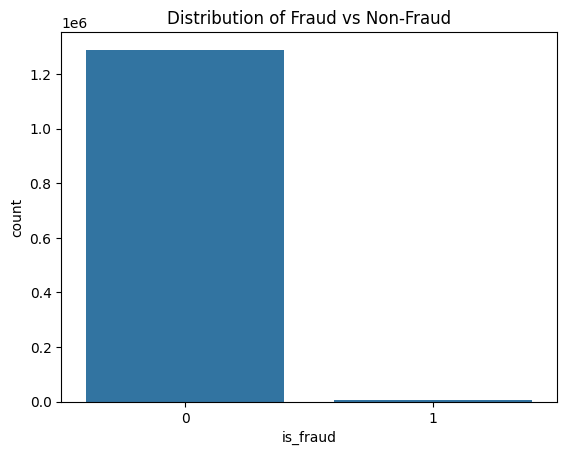

In [55]:
# Distribution Plot of the target variable (fraud/no-fraud)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=fraud_data, x='is_fraud')
plt.title('Distribution of Fraud vs Non-Fraud')
plt.show()


In [56]:
#Dropping irrelevanat features from the dataset
fraud_data.drop(columns=['Unnamed: 0','cc_num','first','last','street','zip','unix_time','job','merch_lat','merch_long','dob','merchant'],inplace=True)

In [60]:
fraud_data.drop(columns='trans_num',inplace=True,axis=1)

In [61]:
fraud_data.head()

,trans_date_trans_time,category,amt,gender,city,state,lat,long,city_pop,is_fraud
0,2019-01-01 00:00:18,misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,3495,0
1,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,0
2,2019-01-01 00:00:51,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,4154,0
3,2019-01-01 00:01:16,gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,1939,0
4,2019-01-01 00:03:06,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,99,0


Label Encoding

In [62]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le2=LabelEncoder()
le3=LabelEncoder()
le4=LabelEncoder()
fraud_data['gender']=le.fit_transform(fraud_data['gender'])
fraud_data['category']=le2.fit_transform(fraud_data['category'])
fraud_data['city']=le3.fit_transform(fraud_data['city'])
fraud_data['state']=le4.fit_transform(fraud_data['state'])

In [63]:
#processing transaction date and transaction time differently
fraud_data['trans_date_trans_time']=pd.to_datetime(fraud_data['trans_date_trans_time'])

In [70]:
fraud_data.head()

,category,amt,gender,city,state,lat,long,city_pop,is_fraud
0,8,4.97,0,526,27,36.0788,-81.1781,3495,0
1,4,107.23,0,612,47,48.8878,-118.2105,149,0
2,0,220.11,1,468,13,42.1808,-112.2620,4154,0
3,2,45.00,1,84,26,46.2306,-112.1138,1939,0
4,9,41.96,1,216,45,38.4207,-79.4629,99,0


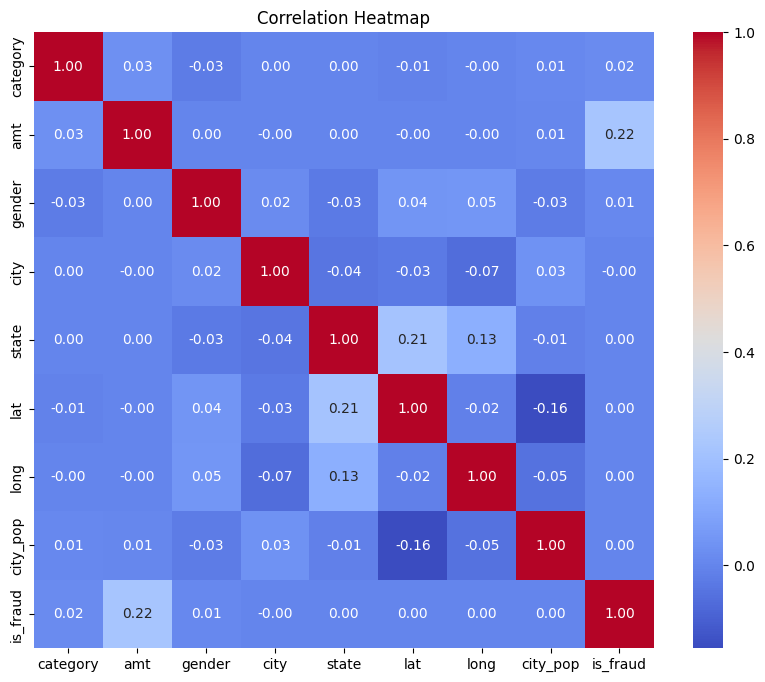

In [71]:
# Plot a heatmap of correlations between numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(fraud_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


This shows that amount is the main feature which affects the value of 'is Fraud'

#Data Splitting

In [72]:
#splitting the data into features and target
X=fraud_data.drop(columns='is_fraud',axis=1)
Y=fraud_data['is_fraud']

In [73]:
X.shape,Y.shape

((1296675, 8), (1296675,))

In [74]:
#dividing the data into training and testing data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [76]:
print(X.shape,X_train.shape,X_test.shape)

(1296675, 8) (1037340, 8) (259335, 8)


# SMOTE

In [79]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

# Check the class distribution after SMOTE
print("Class distribution after SMOTE:", pd.Series(Y_train_resampled).value_counts())


Class distribution after SMOTE: is_fraud
0    1031335
1    1031335
Name: count, dtype: int64


This creates synthetic minority points so as to handle imbalanced dataset and it is applied after splitting into traiining and testing data to avoid data leakage

#Model Training

In [97]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Train the model on the resampled data
model.fit(X_train_resampled, Y_train_resampled)


RandomForestClassifier(random_state=42)

In [104]:
import pandas as pd

# Get feature importances and names
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better readability
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the top features
print(feat_imp_df)


    Feature  Importance
1       amt    0.697275
0  category    0.119511
7  city_pop    0.040823
5       lat    0.037819
6      long    0.035508
3      city    0.031285
4     state    0.027918
2    gender    0.009861


Gender ,State and City columns having less feature importance can also be removed but may lead to precision error

In [106]:
y_pred=model.predict(X_test)

In [107]:
from sklearn.metrics import precision_score
print(precision_score(y_pred,Y_test))

0.7554963357761493


In [109]:
print(accuracy_score(y_pred,Y_test))

0.9825052538222762


In [111]:
print(confusion_matrix(y_pred,Y_test))
#confusion matrix shows the no of flase postives, true postives and false negatives and true negatives as well

[[253664    367]
 [  4170   1134]]


#Model Evaluation on test data

In [120]:
test_data=pd.read_csv('/content/fraud_dataset/fraudTest.csv')

In [121]:
test_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [122]:
test_data.shape

(555719, 23)

In [123]:
#dropping certain columns
test_data.drop(columns=['Unnamed: 0','cc_num','first','last','street','zip','unix_time','job','merch_lat','merch_long','dob','merchant'],inplace=True)

In [124]:
#encoding the categorical columns
test_data['gender']=le.fit_transform(test_data['gender'])
test_data['category']=le2.fit_transform(test_data['category'])
test_data['city']=le3.fit_transform(test_data['city'])
test_data['state']=le4.fit_transform(test_data['state'])

In [126]:
test_data.drop(columns={'trans_date_trans_time','trans_num'},inplace=True)

In [127]:
test_data.head()

,category,amt,gender,city,state,lat,long,city_pop,is_fraud
0,10,2.86,1,157,39,33.9659,-80.9355,333497,0
1,10,29.84,0,16,43,40.3207,-110.4360,302,0
2,5,41.28,0,61,33,40.6729,-73.5365,34496,0
3,9,60.05,1,764,8,28.5697,-80.8191,54767,0
4,13,3.19,1,247,21,44.2529,-85.0170,1126,0


In [128]:
Y_test2=test_data['is_fraud']
X_test2=test_data.drop(columns='is_fraud',axis=1)

In [129]:
Y_pred_test2=model.predict(X_test2)
print("Accuracy Score on testing data: ",accuracy_score(Y_pred_test2,Y_test2))

Accuracy Score on testing data:  0.97728888161103


In [130]:
print(precision_score(Y_pred_test2,Y_test2))

0.6741258741258741


The precison score of nearly 70% shows that the model minimizes the no of false postivies while ensuring high accuracy